# **# Alyssa Antonio and Kit Wong**

# Section 1: Problem and Population. One paragraph. Persona, failure point, SDG. Note anything that changed since M1 and why.

Dave Phillips, San Jose city council member, is responsible for the city's policies regarding food access. He is trying to improve food access for low-income residents in neighborhoods where grocery options are limited and the cost of living is high. Food insecurity in San Jose is caused by affordability and accessibility. Although food banks and assistance programs exist, residents struggle to locate reliable and up to date information about nearby resources. Some also face barriers like transportation and eligibility requirements.
The key failure point is that some data is outdated and inaccurate making it difficult for users. Users also aren't given transportation options and real-time availability.
AI cannot fully understand real-world accessibility factors making it not very helpful for the user, especially those without transportation.

# Section 2: Proposed System. Input → AI processing → output → real-world action. Diagram or structured description.

The user can input that they're struggling with finding something to feed their family for dinner along with their location and city where they live. The AI is given instruction to find the nearest food banks and pantries to the user based on their location. The AI's output is a list of nearby food banks and pantries, along with the addresses, phone numbers, and website links. The AI also gives tips and guidance that fits best for their current situation. For real-world action, the user can go to the listed food banks to retrieve food. AI suggests letting the food banks know about their current food situation and bring their ID just in case beacuse some places may ask for it.

# Section 3: Project Code. Select at least two labs that best support your system and modify to your project. For each: include the code cell, preserve the output, and explain in a text cell what it demonstrates about your system. The selection and explanation are the work. You are encouraged to use AI to help you debug your code.

# Lab 2: For lab 2, the user is able to locate nearby food banks and pantries near their location provided. The AI generates a list of different food banks along with information and resources that are helpful to the user.

In [ ]:
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

Gemini initialized successfully.


In [ ]:
resident_message = (
    "I am low on food to feed my family tonight. I live in downtown San Jose"
)
# example resident request sent to AI system that simulates a real-world situationr regarding food assistance in Downtown San Jose

def extract_unstructured(message): # the purpose of this function is to send the resident's message to Gemini AI model and find nearby food banks/pantries
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash", #works for simple text generation tasks
        system_instruction="Find nearby food banks and pantries in downtown san jose"
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    return response.text #this is used to return only the text portion of AI response

print("--- Resident message ---") #displays the resident's message and input being provided to AI system
print(resident_message)
print("\n--- Unstructured extraction (run 3 times — notice the format changes) ---")
print("\nRun 1:")
print(extract_unstructured(resident_message))
print("\nRun 2:")
print(extract_unstructured(resident_message))
print("\nRun 3:")
print(extract_unstructured(resident_message)) # it is ran multiple times to produce slightly different outputs and formatting

--- Resident message ---
I am low on food to feed my family tonight. I live in downtown San Jose

--- Unstructured extraction (run 3 times — notice the format changes) ---

Run 1:
I'm so sorry to hear you're in this difficult situation. It takes courage to reach out, and I want to help you find food for your family tonight in downtown San Jose.

Here are the most immediate and accessible options, especially for those in the downtown area. **Please call ahead to confirm their current hours and any specific requirements (like ID) before you go.**

---

### **Immediate Options in Downtown San Jose:**

1.  **CityTeam San Jose**
    *   **What they offer:** Often provides hot meals and sometimes emergency food boxes.
    *   **Address:** 1174 H Keyes St, San Jose, CA 95112 (This is very close to downtown)
    *   **Phone:** (408) 293-3050
    *   **Hours:** They typically serve dinner in the evenings. **Call them immediately to confirm meal times for tonight.**

2.  **Loaves & Fishes Family

Description of the Output above:

The output of this code first prints out the resident's original message so the user can confirm the exact prompt being sent to the AI model. The code runs three separate times using the same prompt. Each prompt contains a nearby food bank/pantry, address, phone number or website, operating hours, and next steps for the user. The “nearby” food banks are based on the location provided by the user. In this case, the AI gives food banks located around the downtown San Jose area. The Important tips and directions on how to access food through the websites are included, which could be very useful information for the user. Each run may look a little different in formatting and wording since some responses may be outdated or inaccurate.


# Lab 3: For Lab 3, the user is able to input a photo of their location. AI will analyze the photo to determine the location, then use that information to find food banks that are closest to them. AI also provides information on public transportation that can take them to the locations provided. This could be useful for older residents as it's simple as inputting a screenshot of their location.

In [ ]:
!pip install -q google-generativeai Pillow

In [ ]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


In [ ]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


Saving Image 5-4-26 at 2.01 PM.png to Image 5-4-26 at 2.01 PM (1).png
Uploaded: Image 5-4-26 at 2.01 PM (1).png
Image size: 2880x1800 pixels


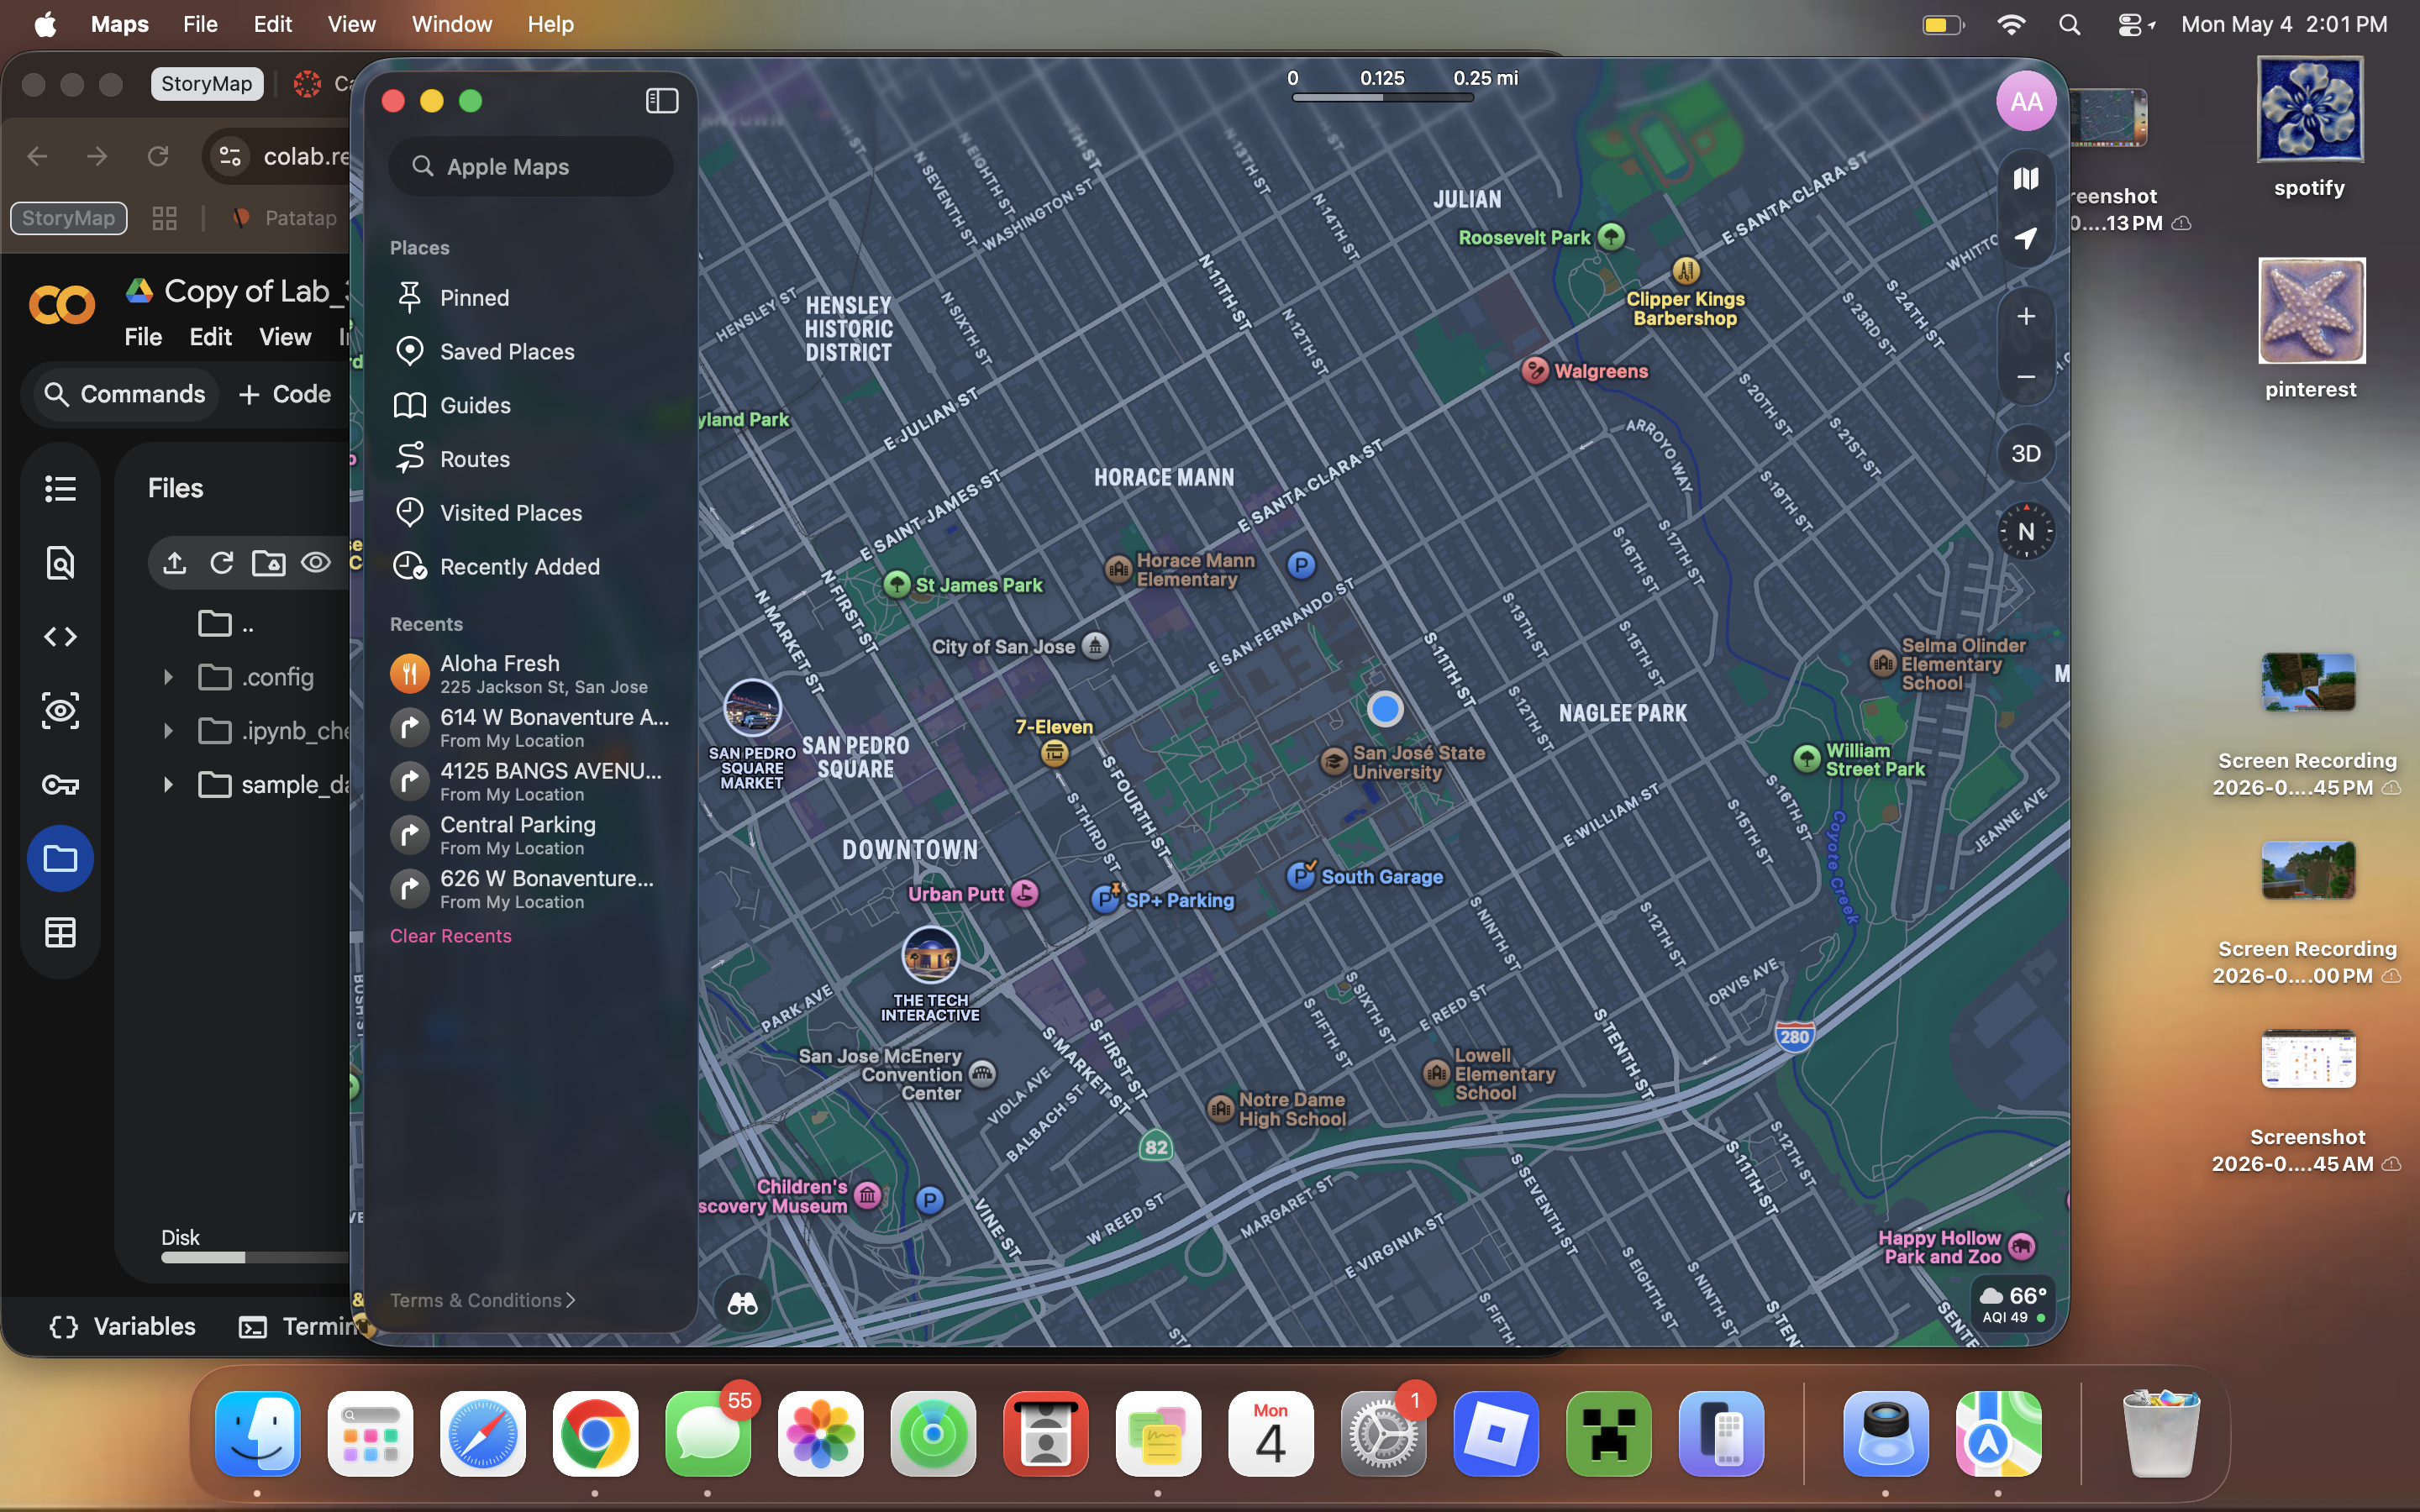

--- LOCATION ---
The map displayed shows a detailed view of a section of **San Jose, California, USA**.

The primary focus appears to be on the **Downtown** area and its immediate surroundings, with **San Jose State University** prominently located near the center of the visible map (marked with a blue dot, likely indicating a current or selected location).

Key districts and landmarks visible include:
*   **Hensley Historic District** in the northwest.
*   **San Pedro Square** and **San Pedro Square Market** in the west-central area.
*   **Horace Mann** and **Naglee Park** neighborhoods to the northeast and east, respectively.
*   **The Tech Interactive** and **Children's Discovery Museum** in the southwest.
*   **San Jose McEnery Convention Center** also in the southwest.
*   Parks such as **St James Park**, **Roosevelt Park**, **William Street Park**, and **Happy Hollow Park and Zoo** (in the southeast).

The street layout largely follows a grid pattern, with many north/south street

In [ ]:
#Uploaded image is expected to be a screenshot of a map so the AI can analyze the picture and identify the location to find nearby food assistance resources
uploaded = files.upload()

# Retrieves the filename so it can be opened and analyzed
image_filename = list(uploaded.keys())[0]

# Open and display the uploaded image to confirm with the user which image is being analyzed by the AI
img = PILImage.open(image_filename) #Opens the uploaded image file
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels") #Returns the image dimensions in pixels
display(img) #displays the uploaded image

#The following prompts guide the AI to analyze the uploaded image and make conclusions based on food insecurity and accessibility
civic_questions = [
    ("LOCATION",  "Describe the location, not the image, on the map visible in this image."), #identifies the area shown in image
    ("ACTION",   "Based on the location, not the image locate neaby food banks, soup-kitchens, and pantries that are availible at this instance? What action should they take?"), #finds nearby food banks then suggests what actions the user should take
    ("NUMBER",   "How places on the map can you see that provide food of low cost that are accessible to anyone?"), #shows how many low-cost food resources are available nearby
    ("ACCESSIBILITY",  "How accessible are these places via public transportation?"), #confirms whether public transportation could be realistically taken to help users go to these nearby resources
]

civic_results = {"answers": {}, "total_tokens": 0} #"answers" keeps the reponses organized by question

for label, question in civic_questions: #loops through each civic question
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question) #analyzes uploaded image using the AI model
    civic_results["answers"][label] = answer #stores answer to question under a label
    civic_results["total_tokens"] += usage.total_token_count
    print(answer) #displays AI generated response
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

Description of the Output above:

The output demonstrates how the AI analyzed and interpreted the uploaded  screenshot for the food insecurity assistance project. First, the system successfully uploaded and processed the image, identifying the map as a section of San Jose centered around downtown and San Jose State University. The AI used image recognition to identify nearby landmarks, neighborhoods, parks, businesses, and major roads, showing that the system can determine a user’s approximate location without requiring them to manually type their address.  After identifying the location, the AI transitioned into generating food assistance recommendations and guidance. The AI also instructed the user to further verify operating hours and to use directions for transportation.
Overall, the output demonstrates both the strengths and weaknesses of the system: the AI is effective at interpreting map images and generating location-based assistance, but it can still provide generalized, inaccurate, or incomplete recommendations without human oversight and updated real-time data (as portrayed in the Accessibility section).




# Section 4: Edge Case Elicitation. Design and run a prompt intended to surface a failure in your system. Target one of: an input the system wasn't designed for, a user outside the assumed majority, or a condition that makes the AI's confidence misleading. Preserve the output. In a text cell, document the prompt, the output, and a one-sentence assessment: failure, near-miss, or acceptable.

In [ ]:
questions = [
    ("LOCATION",  "Describe the location, not the image, on the map visible in this image."),
    ("ACTION",   "Based on the city in the map shown, which food banks are currently open right now and have food available at this exact time?"),
]

civic_results = {"answers": {}, "total_tokens": 0}

for label, question in questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer.replace('\\', '\\\\')) # Fix: Escape backslashes in the output string
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- LOCATION ---
The map visible in the image displays a detailed section of **San Jose, California**, primarily focusing on its **downtown area** and adjacent neighborhoods.

Here's a breakdown of the location:

*   **Central Feature:** **San Jose State University** is a prominent landmark near the center of the map, with the general **Downtown** district situated directly to its west and northwest.
*   **Street Layout:** The area is characterized by a dense, mostly gridded street pattern. Major north-south arteries are numbered (e.g., N First St, S First St, S 4th St), while east-west streets often have names (e.g., E Julian St, E Santa Clara St, E San Fernando St, E William St).
*   **Key Districts/Neighborhoods:**
    *   **Hensley Historic District** is located in the northwest.
    *   **Horace Mann** is to the north-central area.
    *   **Naglee Park** is situated to the east.
*   **Parks and Green Spaces:**
    *   **St James Park** is north of the Downtown area.
    *   **Roo

# I would consider this a failure because the AI is not able to provide food banks in the city and availability like it is asked to. The AI is asked to find food banks in the city of the map shown, not food banks based on the image.